In [ ]:
# Notebook imports
# Generated from standard/third-party imports used throughout this notebook.
import glob
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay, jaccard_score, precision_score, recall_score


In [1]:

# Set base directories
BASE_DIR = "/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28"
GRAHA_DIR = os.path.join(BASE_DIR, "graha_model", "last")
TOY_DIR = os.path.join(BASE_DIR, "toy_model", "last")

# Get a list of all patch directories (e.g., M1098029461CE_r2850_c450)
# We assume the same patches exist in both model directories
patch_dirs = [d for d in os.listdir(GRAHA_DIR) if os.path.isdir(os.path.join(GRAHA_DIR, d))]
print(f"Found {len(patch_dirs)} patches to process.")

Found 100 patches to process.


Visualizing the first 30 chips...



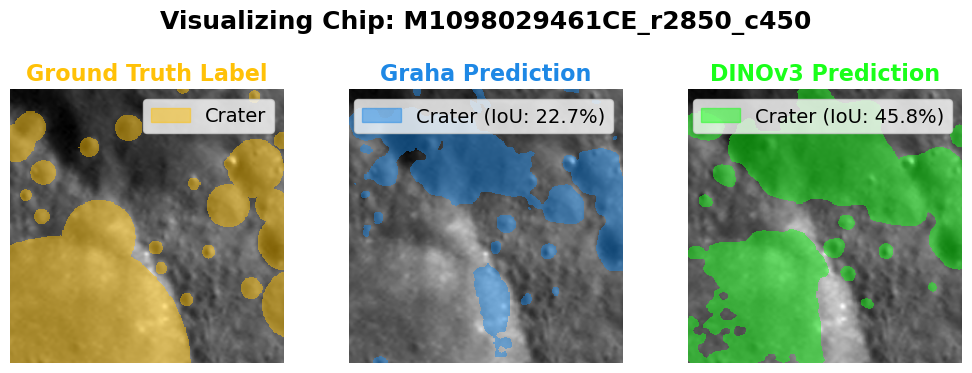

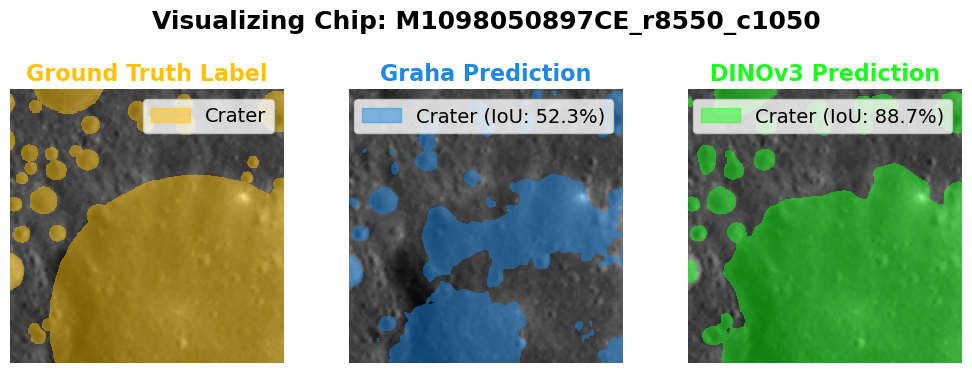

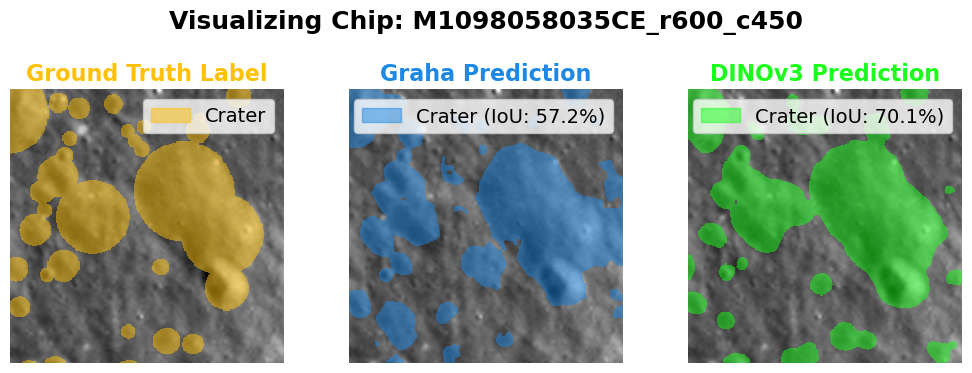

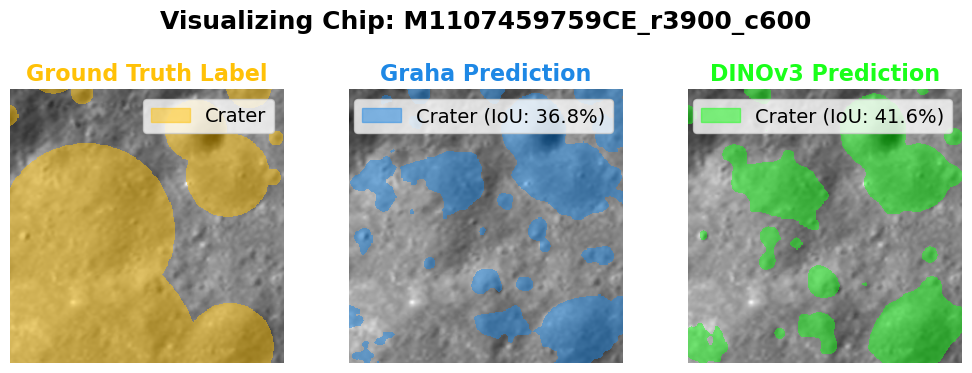

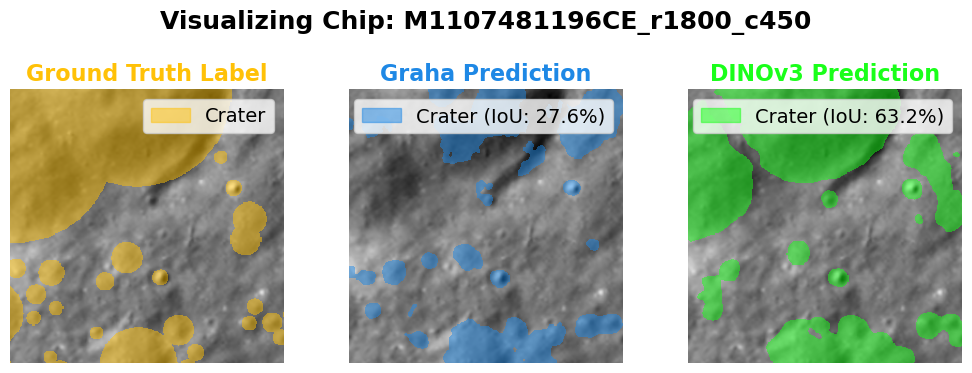

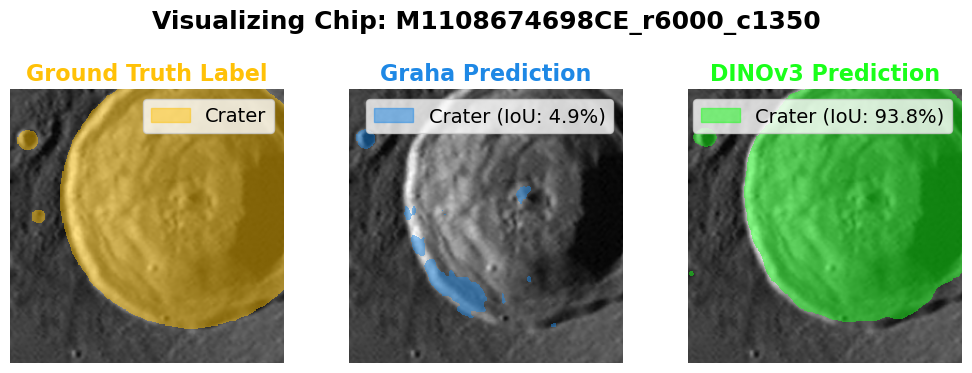

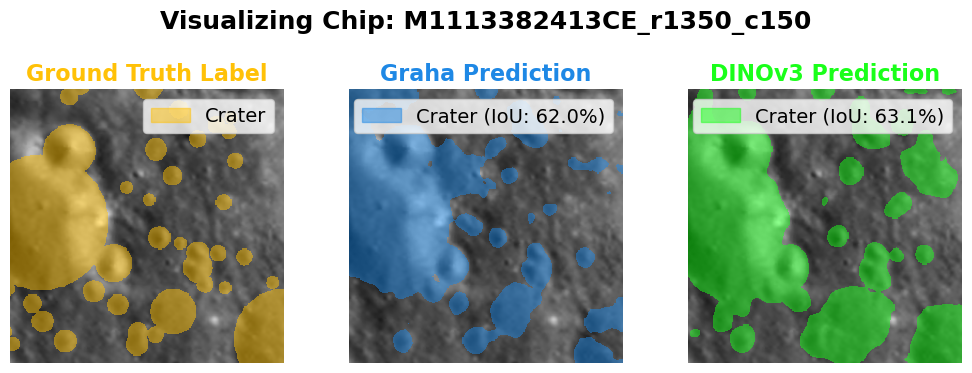

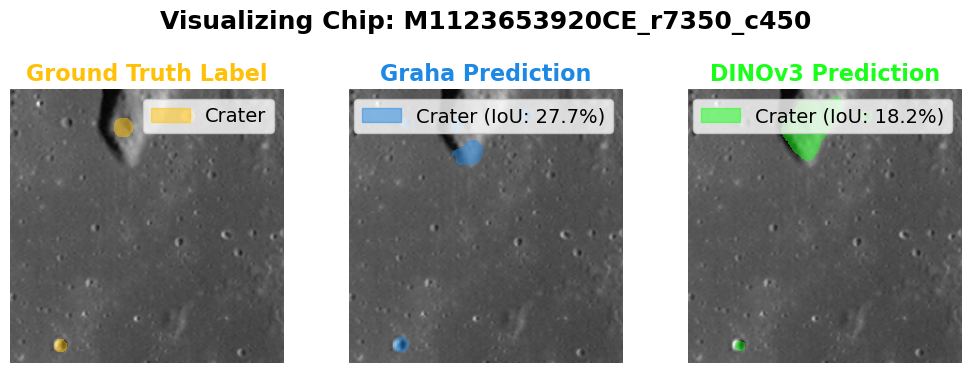

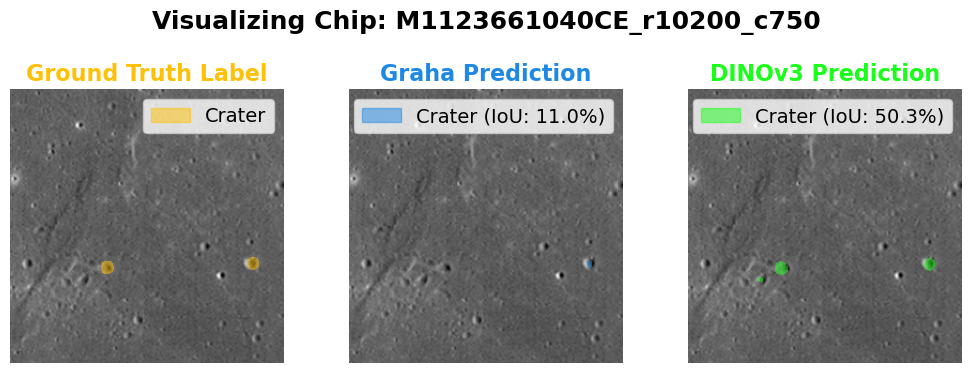

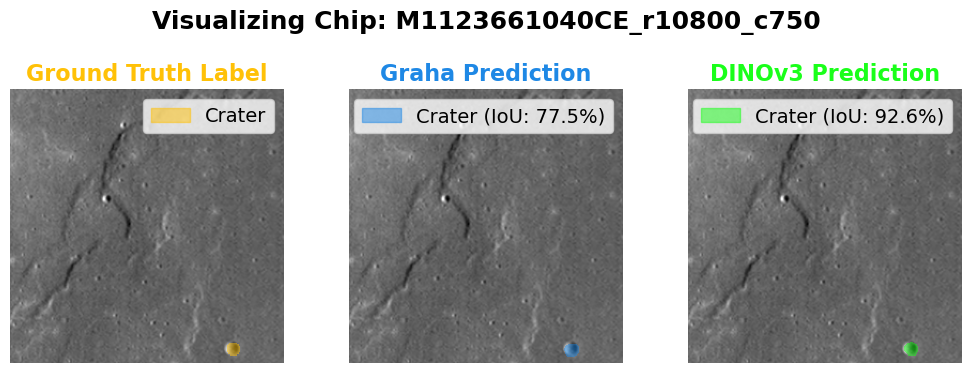

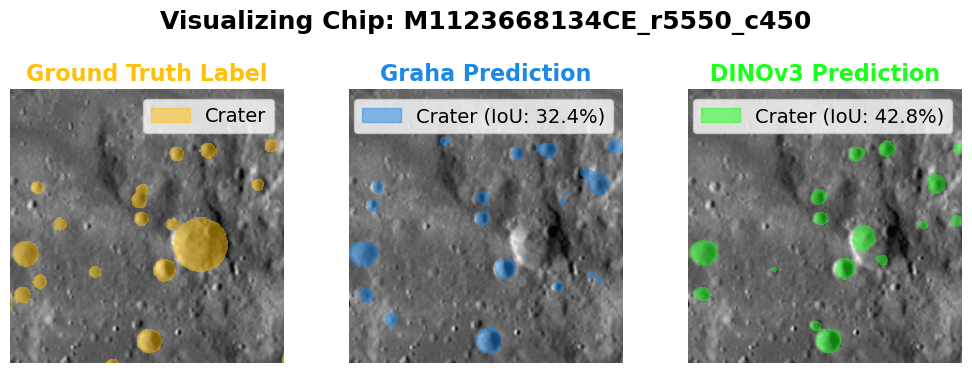

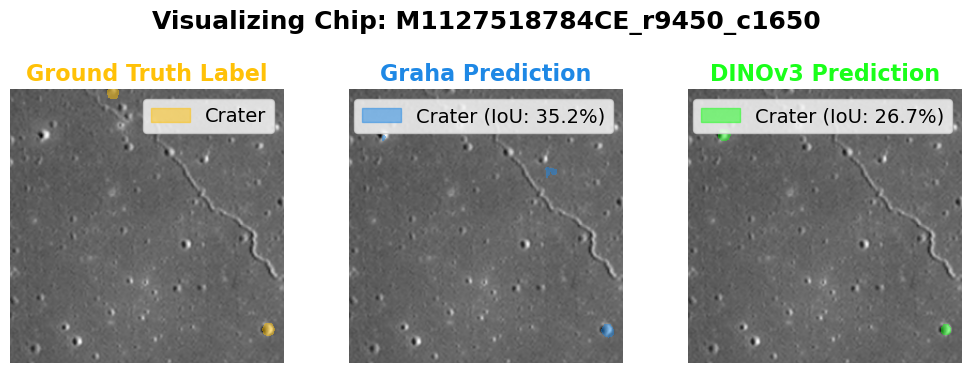

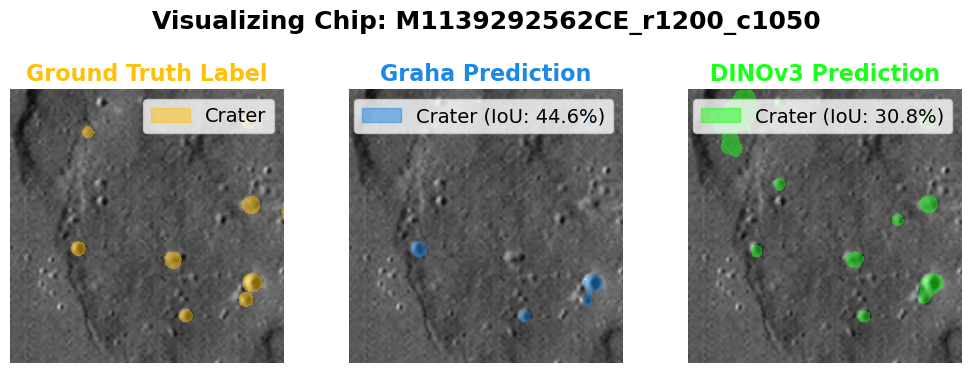

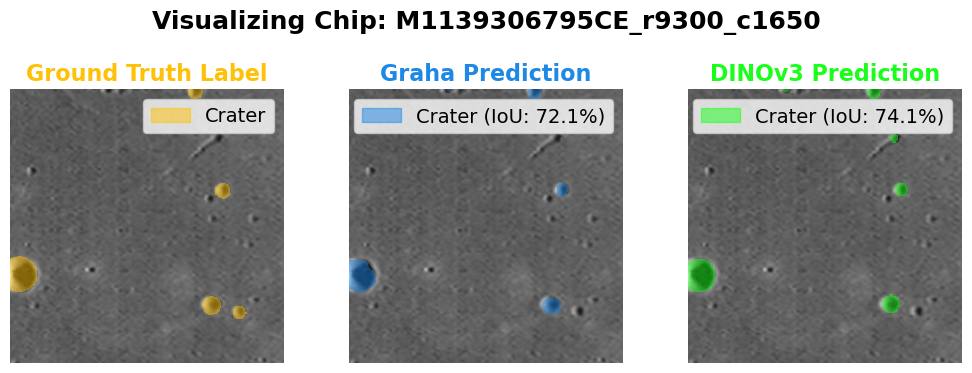

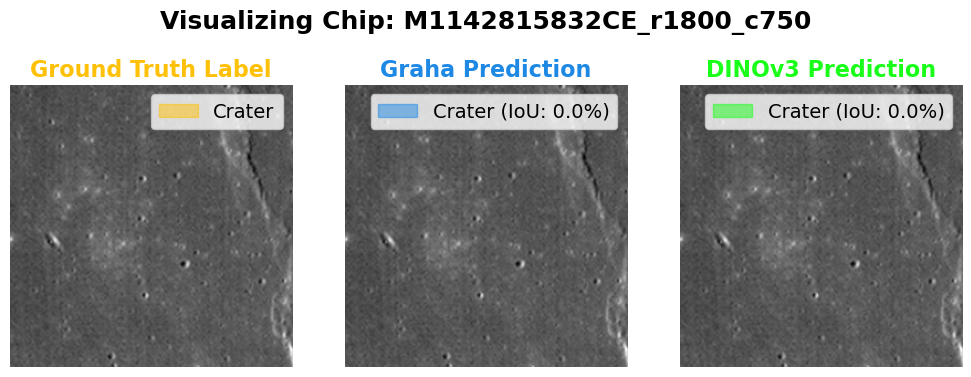

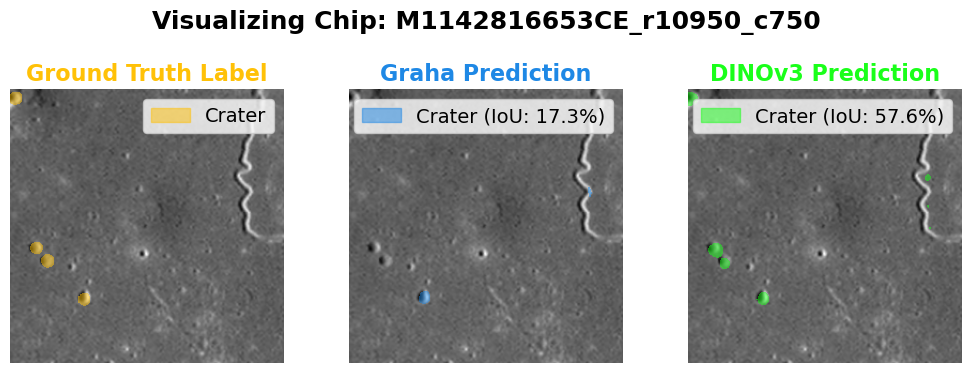

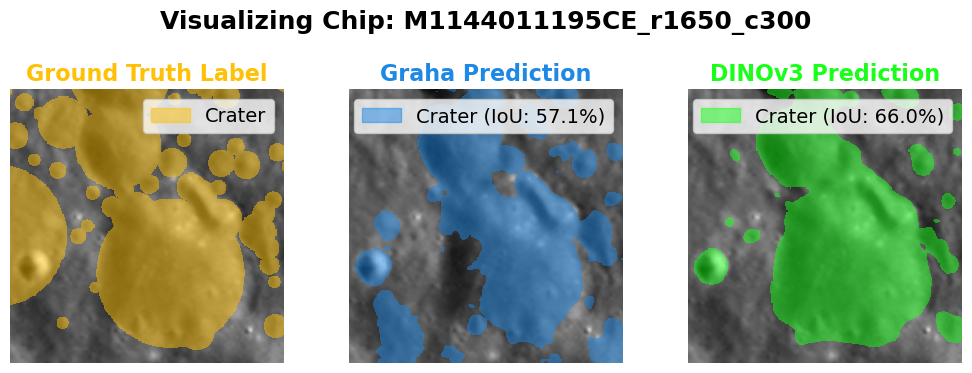

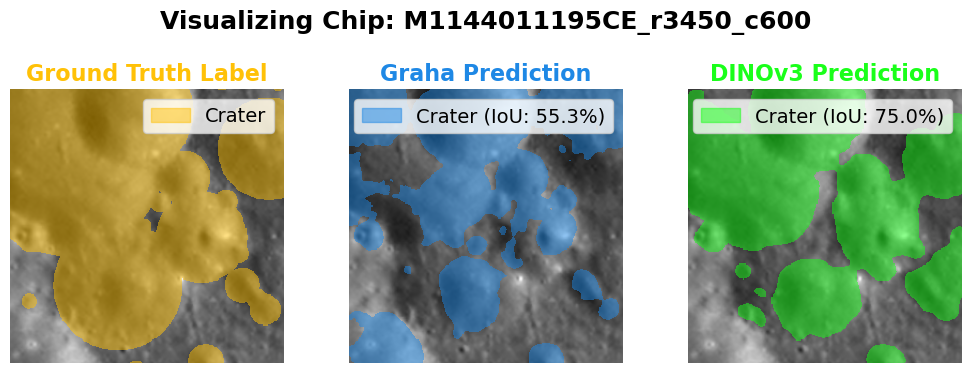

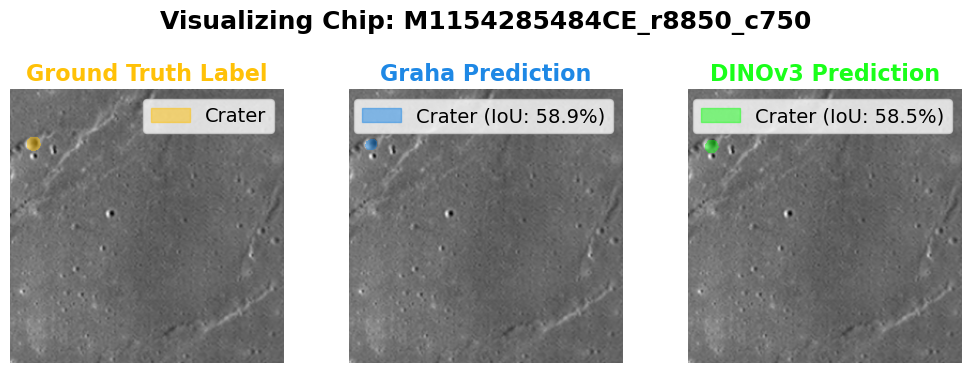

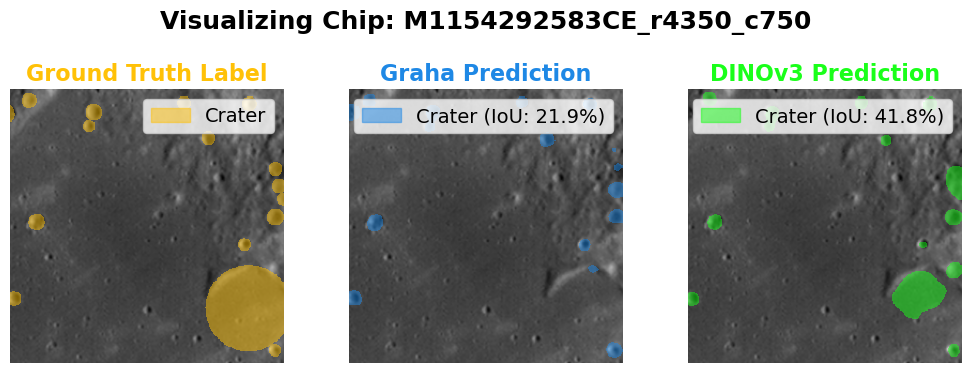

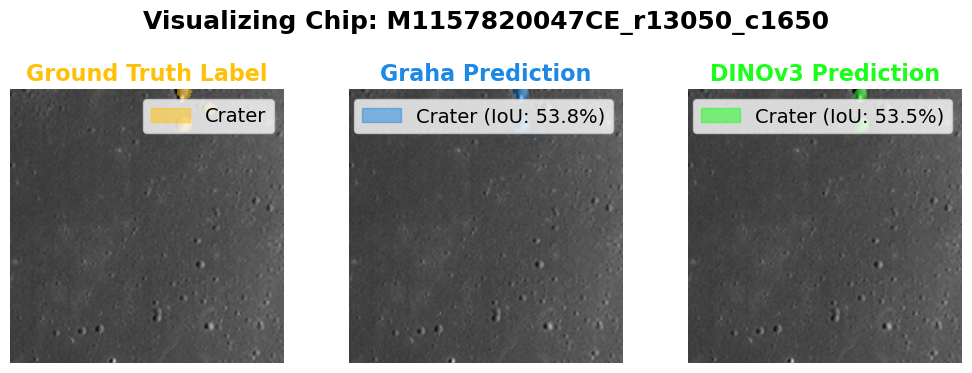

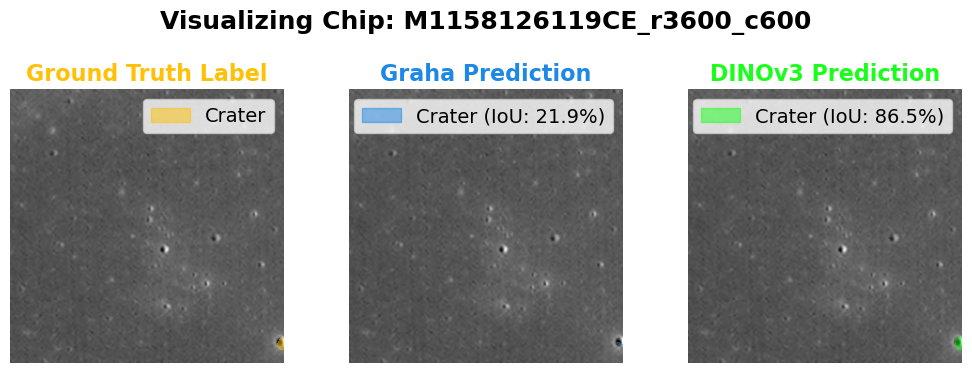

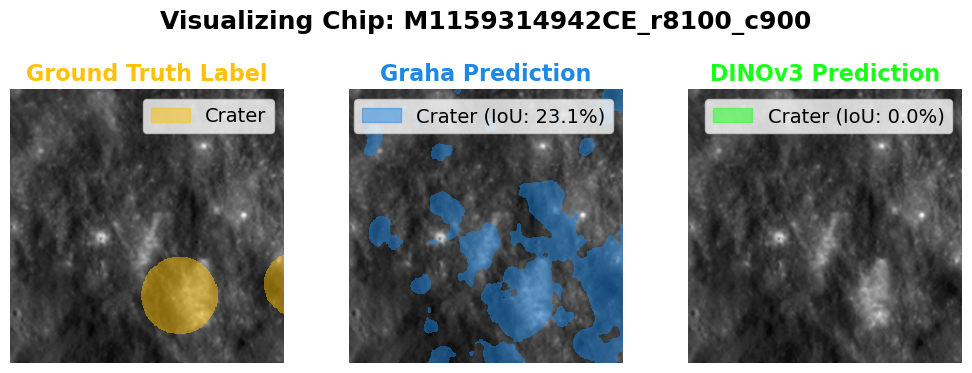

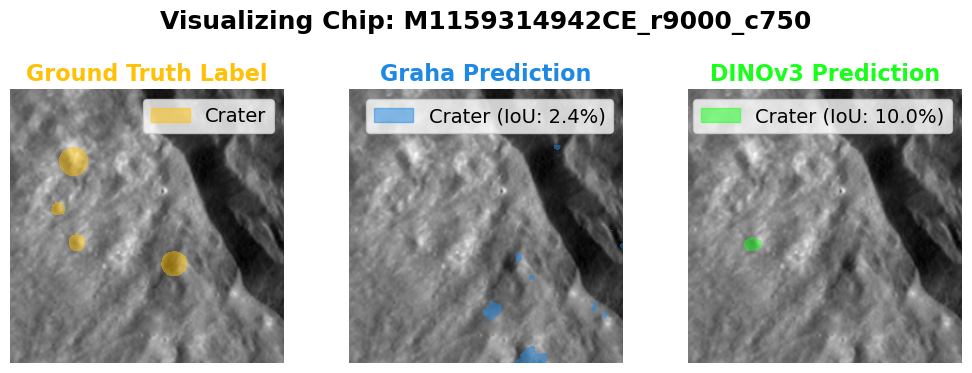

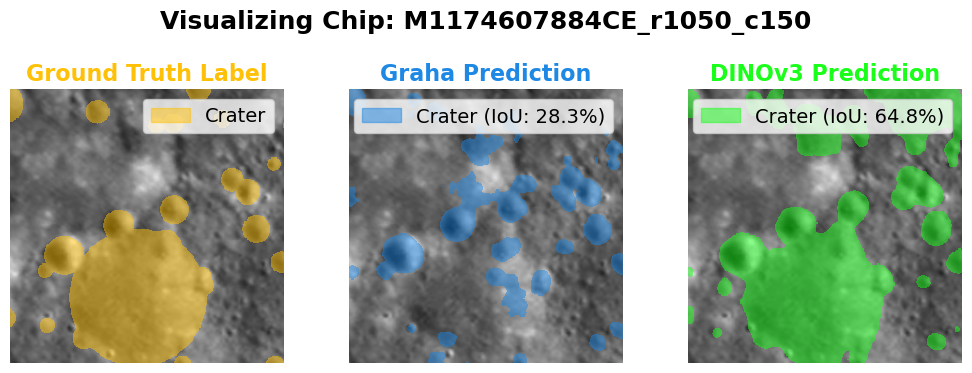

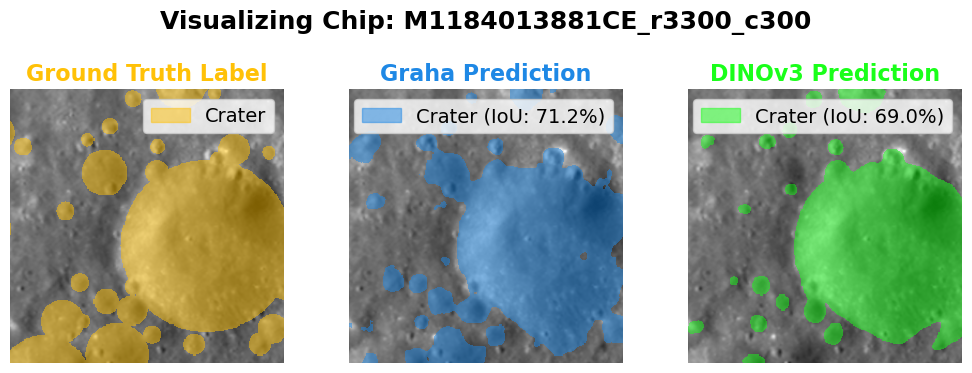

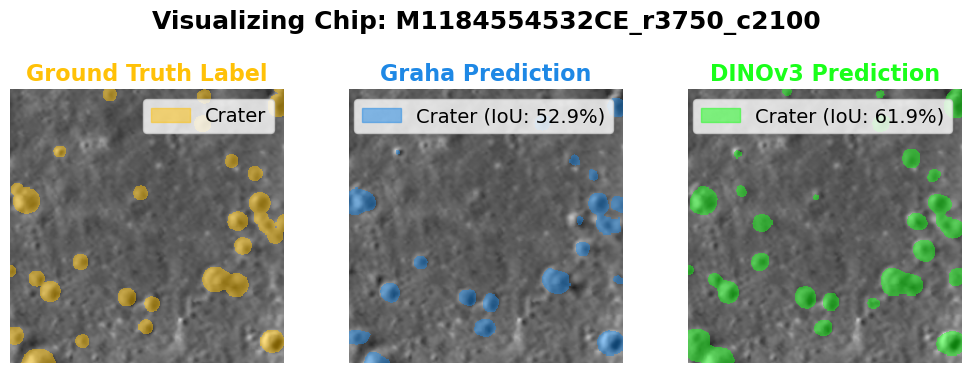

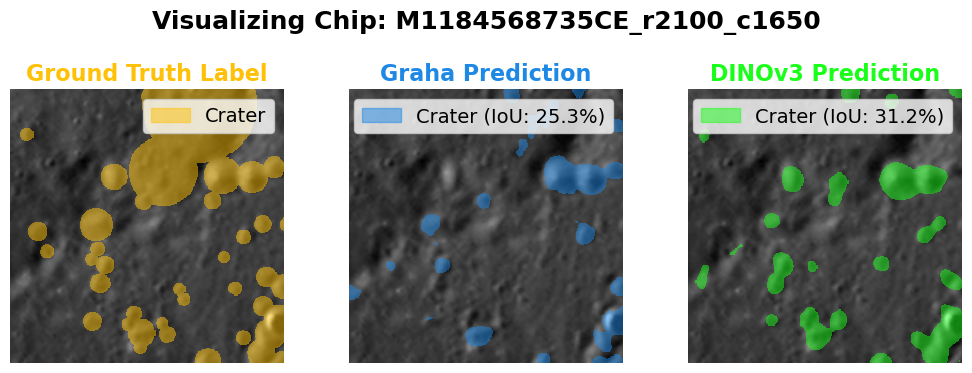

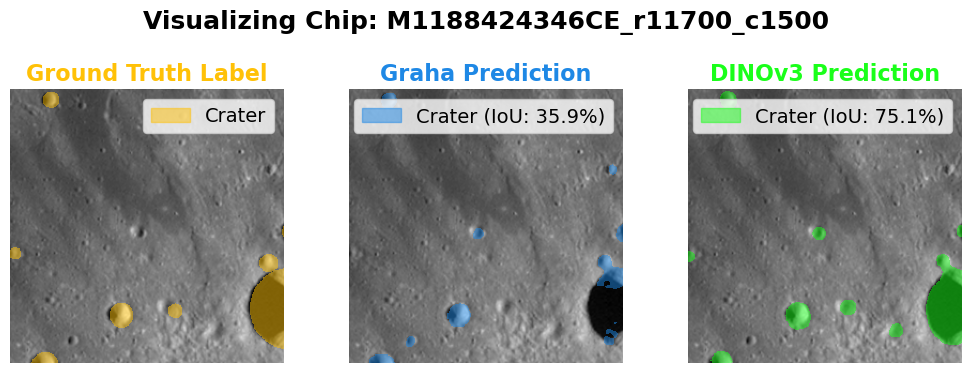

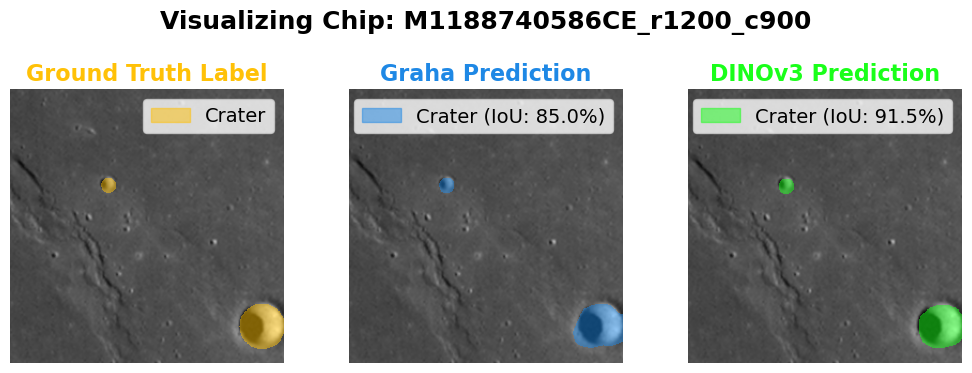

In [2]:

# --- SET GLOBAL FONT SIZE ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Set base directories
BASE_DIR = "/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28"
GRAHA_DIR = os.path.join(BASE_DIR, "graha_model", "last")
DINO_DIR = os.path.join(BASE_DIR, "toy_model", "last") 

# --- Helper Function for Colored Overlays ---
def create_overlay(mask, hex_color, alpha=0.5):
    rgb = mcolors.to_rgb(hex_color)
    overlay = np.zeros((*mask.shape, 4)) 
    overlay[..., :3] = rgb               
    overlay[..., 3] = mask * alpha       
    return overlay

COLOR_GT = "#FFC107"
COLOR_GRAHA = "#1E88E5"
COLOR_DINO = "#1AFF1A"

patch_dirs = [d for d in os.listdir(GRAHA_DIR) if os.path.isdir(os.path.join(GRAHA_DIR, d))]
NUM_CHIPS = 30 

print(f"Visualizing the first {NUM_CHIPS} chips...\n")

for sample_chip in patch_dirs[:NUM_CHIPS]:
    input_path = os.path.join(GRAHA_DIR, sample_chip, f"{sample_chip}_input.npy")
    label_path = os.path.join(GRAHA_DIR, sample_chip, f"{sample_chip}_label.npy")
    graha_pred_path = os.path.join(GRAHA_DIR, sample_chip, f"{sample_chip}_pred.npy")
    dino_pred_path = os.path.join(DINO_DIR, sample_chip, f"{sample_chip}_pred.npy")

    graha_metrics_path = os.path.join(GRAHA_DIR, sample_chip, "metrics.npy")
    dino_metrics_path = os.path.join(DINO_DIR, sample_chip, "metrics.npy")

    if not os.path.exists(input_path): continue
        
    input_img = np.load(input_path)
    label_img = np.load(label_path)
    graha_pred = np.load(graha_pred_path)
    dino_pred = np.load(dino_pred_path)

    graha_iou_str = "N/A"
    if os.path.exists(graha_metrics_path):
        graha_metrics = np.load(graha_metrics_path, allow_pickle=True)
        if graha_metrics.ndim == 0: graha_metrics = graha_metrics.item() 
        graha_iou_str = f"{graha_metrics[4] * 100:.1f}%"

    dino_iou_str = "N/A"
    if os.path.exists(dino_metrics_path):
        dino_metrics = np.load(dino_metrics_path, allow_pickle=True)
        if dino_metrics.ndim == 0: dino_metrics = dino_metrics.item() 
        dino_iou_str = f"{dino_metrics[4] * 100:.1f}%"

    img_to_plot = input_img[0]
    label_mask = label_img[0] if label_img.ndim == 3 else label_img
    graha_mask = graha_pred[0] if graha_pred.ndim == 3 else graha_pred
    dino_mask = dino_pred[0] if dino_pred.ndim == 3 else dino_pred

    # --- VISUALIZE OVERLAYS ---
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))

    fig.suptitle(f"Visualizing Chip: {sample_chip}", fontsize=18, fontweight='bold')

    axes[0].imshow(img_to_plot, cmap='gray')
    axes[0].imshow(create_overlay(label_mask, COLOR_GT, alpha=0.5), interpolation='none')
    axes[0].set_title("Ground Truth Label", color=COLOR_GT, fontweight='bold')
    axes[0].axis('off')
    gt_patch = mpatches.Patch(color=COLOR_GT, alpha=0.5, label='Crater')
    axes[0].legend(handles=[gt_patch], loc='upper right')

    axes[1].imshow(img_to_plot, cmap='gray')
    axes[1].imshow(create_overlay(graha_mask, COLOR_GRAHA, alpha=0.5), interpolation='none')
    axes[1].set_title("Graha Prediction", color=COLOR_GRAHA, fontweight='bold')
    axes[1].axis('off')
    graha_patch = mpatches.Patch(color=COLOR_GRAHA, alpha=0.5, label=f'Crater (IoU: {graha_iou_str})')
    axes[1].legend(handles=[graha_patch], loc='upper right')

    axes[2].imshow(img_to_plot, cmap='gray')
    axes[2].imshow(create_overlay(dino_mask, COLOR_DINO, alpha=0.5), interpolation='none')
    axes[2].set_title("DINOv3 Prediction", color=COLOR_DINO, fontweight='bold')
    axes[2].axis('off')
    dino_patch = mpatches.Patch(color=COLOR_DINO, alpha=0.5, label=f'Crater (IoU: {dino_iou_str})')
    axes[2].legend(handles=[dino_patch], loc='upper right')

    plt.tight_layout()
    plt.show()

In [16]:

# Set base directories
BASE_DIR = "/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28"
GRAHA_DIR = os.path.join(BASE_DIR, "graha_model", "last")
DINO_DIR = os.path.join(BASE_DIR, "toy_model", "last") 

# Get list of patches/chips
patch_dirs = [d for d in os.listdir(GRAHA_DIR) if os.path.isdir(os.path.join(GRAHA_DIR, d))]

metrics_data = []
all_labels = []
all_graha_preds = []
all_dino_preds = []

print(f"Processing {len(patch_dirs)} chips to load data and calculate 7 metrics...")

for chip in patch_dirs:
    label_path = os.path.join(GRAHA_DIR, chip, f"{chip}_label.npy")
    graha_pred_path = os.path.join(GRAHA_DIR, chip, f"{chip}_pred.npy")
    dino_pred_path = os.path.join(DINO_DIR, chip, f"{chip}_pred.npy")
    
    if os.path.exists(label_path) and os.path.exists(graha_pred_path) and os.path.exists(dino_pred_path):
        
        # Load and flatten the arrays
        lbl = np.load(label_path).flatten()
        g_pred = np.load(graha_pred_path).flatten()
        d_pred = np.load(dino_pred_path).flatten()
        
        # Append to global lists for the confusion matrix (Cell 3)
        all_labels.extend(lbl)
        all_graha_preds.extend(g_pred)
        all_dino_preds.extend(d_pred)
        
        # We use labels=[0, 1] to ensure the matrix is always 2x2 even if a chip has no craters
        g_tn, g_fp, g_fn, g_tp = confusion_matrix(lbl, g_pred, labels=[0, 1]).ravel()
        d_tn, d_fp, d_fn, d_tp = confusion_matrix(lbl, d_pred, labels=[0, 1]).ravel()
        
        # Calculate Graha
        g_area_bias = (g_tp + g_fp) / (g_tp + g_fn) if (g_tp + g_fn) > 0 else 0
        g_spec = g_tn / (g_tn + g_fp) if (g_tn + g_fp) > 0 else 0
        g_ap = average_precision_score(lbl, g_pred) if np.sum(lbl) > 0 else 0
        
        metrics_data.append({
            "Model": "Graha",
            "Chip": chip,
            "Accuracy": accuracy_score(lbl, g_pred),
            "Precision": precision_score(lbl, g_pred, average='binary', zero_division=0),
            "Recall": recall_score(lbl, g_pred, average='binary', zero_division=0),
            "IoU": jaccard_score(lbl, g_pred, average='binary', zero_division=0),
            "Area Bias": g_area_bias,
            "Specificity": g_spec,
            "Average Precision": g_ap
        })
        
        # Calculate DINOv3
        d_area_bias = (d_tp + d_fp) / (d_tp + d_fn) if (d_tp + d_fn) > 0 else 0
        d_spec = d_tn / (d_tn + d_fp) if (d_tn + d_fp) > 0 else 0
        d_ap = average_precision_score(lbl, d_pred) if np.sum(lbl) > 0 else 0
        
        metrics_data.append({
            "Model": "DINOv3",
            "Chip": chip,
            "Accuracy": accuracy_score(lbl, d_pred),
            "Precision": precision_score(lbl, d_pred, average='binary', zero_division=0),
            "Recall": recall_score(lbl, d_pred, average='binary', zero_division=0),
            "IoU": jaccard_score(lbl, d_pred, average='binary', zero_division=0),
            "Area Bias": d_area_bias,
            "Specificity": d_spec,
            "Average Precision": d_ap
        })

df_metrics = pd.DataFrame(metrics_data)
print("Data loading and metric calculations complete!")

Processing 100 chips to load data and calculate 7 metrics...
Data loading and metric calculations complete!


OVERALL GLOBAL METRICS (All Pixels)
Graha  -> Accuracy ((TP+TN)/Total): 0.8441 | Precision (TP/(TP+FP)): 0.6829 | Recall (TP/(TP+FN)): 0.4615
          IoU (TP/(TP+FP+FN)): 0.3801 | Area Bias ((TP+FP)/(TP+FN)): 0.6758 | Specificity (TN/(TN+FP)): 0.9440 | AP (Area under PR Curve): 0.4267
--------------------------------------------------------------------------------------------------------------------------------------------
DINOv3 -> Accuracy ((TP+TN)/Total): 0.8948 | Precision (TP/(TP+FP)): 0.7929 | Recall (TP/(TP+FN)): 0.6659
          IoU (TP/(TP+FP+FN)): 0.5673 | Area Bias ((TP+FP)/(TP+FN)): 0.8398 | Specificity (TN/(TN+FP)): 0.9546 | AP (Area under PR Curve): 0.5972


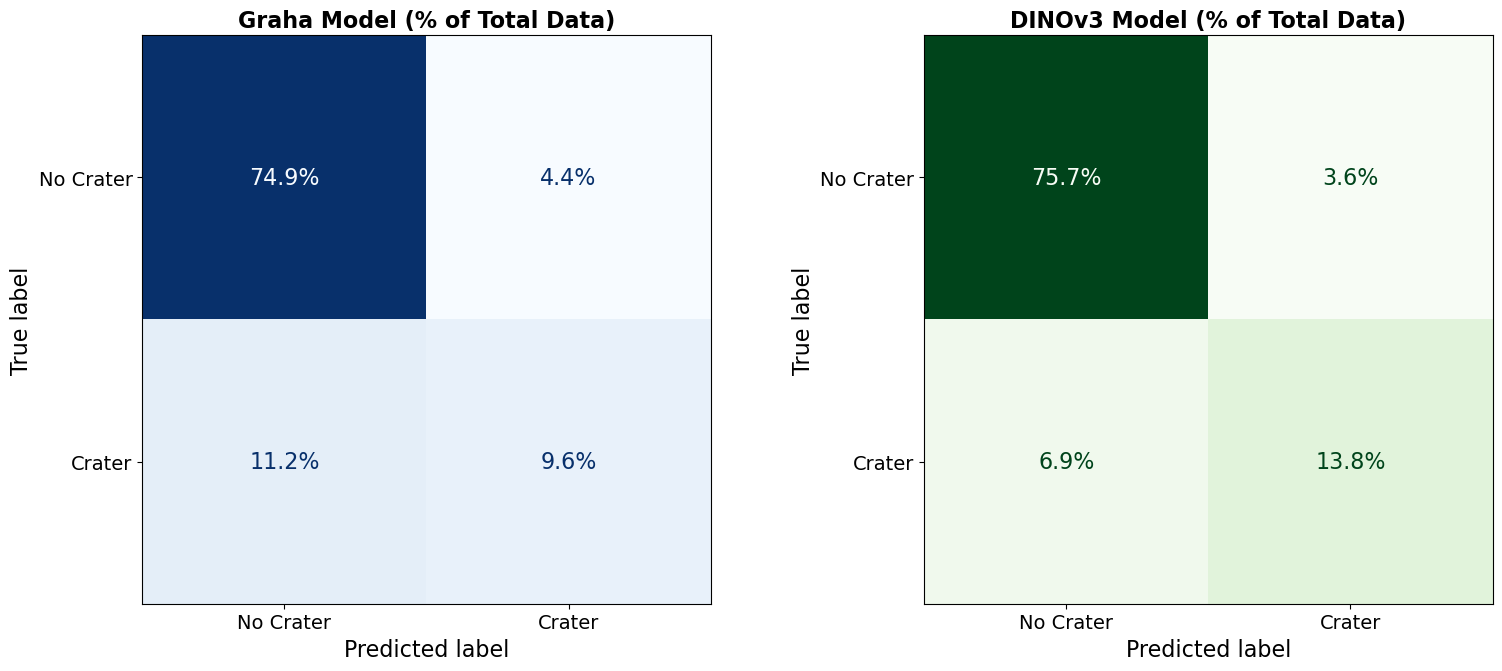

In [15]:

# ==========================================
# 1. CALCULATE METRICS
# ==========================================

# Extract raw counts for Graha
g_tn, g_fp, g_fn, g_tp = confusion_matrix(all_labels, all_graha_preds).ravel()

# Calculate Global Metrics for Graha
g_acc = accuracy_score(all_labels, all_graha_preds)
g_prec = precision_score(all_labels, all_graha_preds, average='binary', zero_division=0)
g_rec = recall_score(all_labels, all_graha_preds, average='binary', zero_division=0)
g_iou = jaccard_score(all_labels, all_graha_preds, average='binary', zero_division=0)
g_area_bias = (g_tp + g_fp) / (g_tp + g_fn) if (g_tp + g_fn) > 0 else 0
g_spec = g_tn / (g_tn + g_fp) if (g_tn + g_fp) > 0 else 0
g_ap = average_precision_score(all_labels, all_graha_preds)

# Extract raw counts for DINOv3
d_tn, d_fp, d_fn, d_tp = confusion_matrix(all_labels, all_dino_preds).ravel()

# Calculate Global Metrics for DINOv3
d_acc = accuracy_score(all_labels, all_dino_preds)
d_prec = precision_score(all_labels, all_dino_preds, average='binary', zero_division=0)
d_rec = recall_score(all_labels, all_dino_preds, average='binary', zero_division=0)
d_iou = jaccard_score(all_labels, all_dino_preds, average='binary', zero_division=0)
d_area_bias = (d_tp + d_fp) / (d_tp + d_fn) if (d_tp + d_fn) > 0 else 0
d_spec = d_tn / (d_tn + d_fp) if (d_tn + d_fp) > 0 else 0
d_ap = average_precision_score(all_labels, all_dino_preds)

# ==========================================
# 2. PRINT METRICS
# ==========================================
print("="*140)
print("OVERALL GLOBAL METRICS (All Pixels)")
print("="*140)
print(f"Graha  -> Accuracy ((TP+TN)/Total): {g_acc:.4f} | Precision (TP/(TP+FP)): {g_prec:.4f} | Recall (TP/(TP+FN)): {g_rec:.4f}")
print(f"          IoU (TP/(TP+FP+FN)): {g_iou:.4f} | Area Bias ((TP+FP)/(TP+FN)): {g_area_bias:.4f} | Specificity (TN/(TN+FP)): {g_spec:.4f} | AP (Area under PR Curve): {g_ap:.4f}")
print("-" * 140)
print(f"DINOv3 -> Accuracy ((TP+TN)/Total): {d_acc:.4f} | Precision (TP/(TP+FP)): {d_prec:.4f} | Recall (TP/(TP+FN)): {d_rec:.4f}")
print(f"          IoU (TP/(TP+FP+FN)): {d_iou:.4f} | Area Bias ((TP+FP)/(TP+FN)): {d_area_bias:.4f} | Specificity (TN/(TN+FP)): {d_spec:.4f} | AP (Area under PR Curve): {d_ap:.4f}")
print("="*140)

# ==========================================
# 3. PLOT CONFUSION MATRICES
# ==========================================
class_names = ["No Crater", "Crater"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graha Matrix
cm_graha = confusion_matrix(all_labels, all_graha_preds, normalize='all')
disp_graha = ConfusionMatrixDisplay(confusion_matrix=cm_graha, display_labels=class_names)
disp_graha.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='.1%')
axes[0].set_title("Graha Model (% of Total Data)", fontweight='bold')

# DINOv3 Matrix
cm_dino = confusion_matrix(all_labels, all_dino_preds, normalize='all')
disp_dino = ConfusionMatrixDisplay(confusion_matrix=cm_dino, display_labels=class_names)
disp_dino.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='.1%')
axes[1].set_title("DINOv3 Model (% of Total Data)", fontweight='bold')

plt.tight_layout()
plt.show()

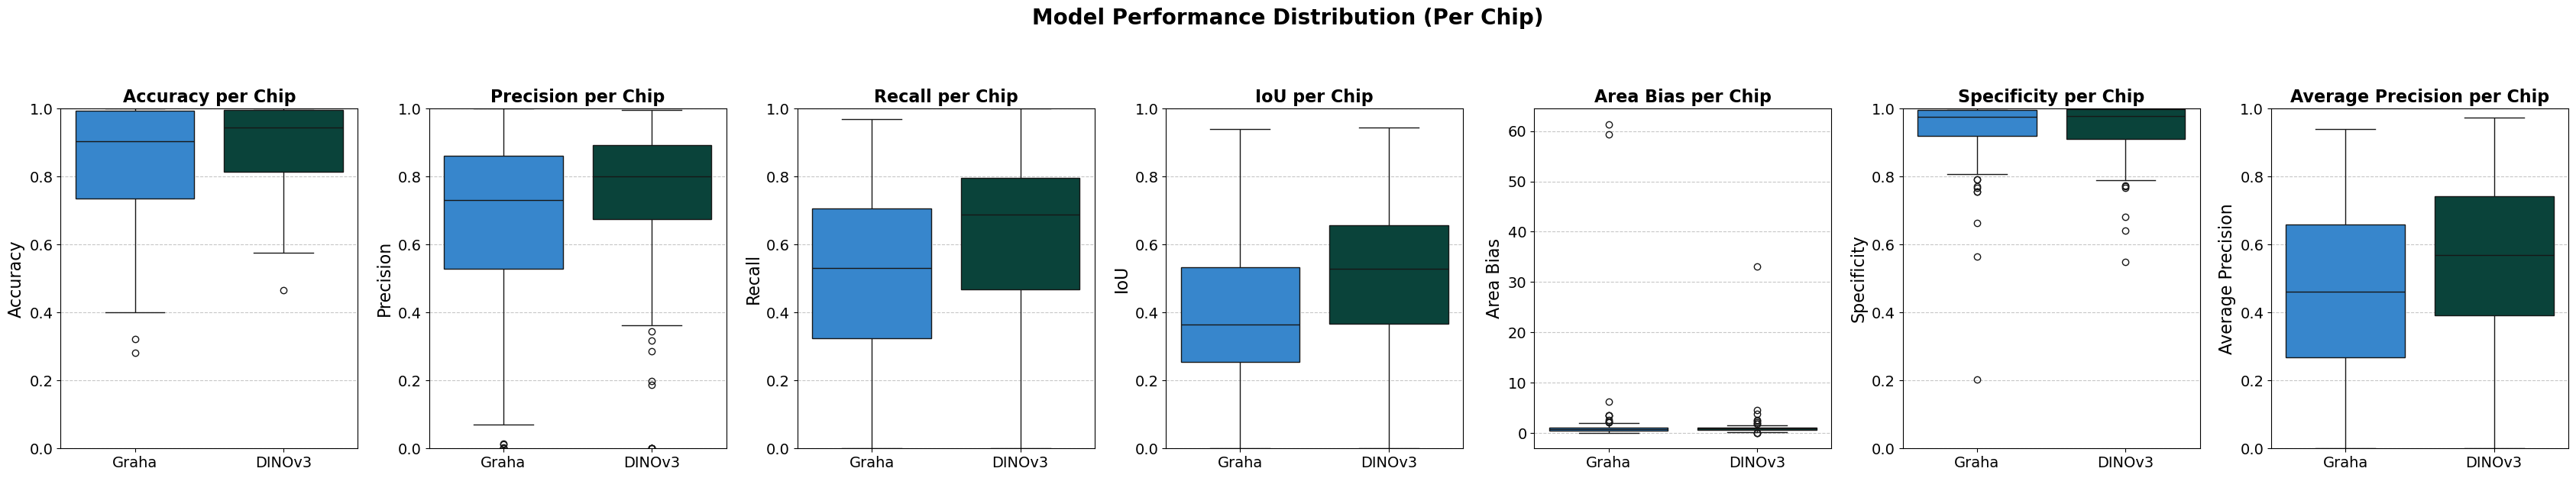

In [17]:

# Set up a 1x7 grid for the plots (to fit all 7 metrics)
fig, axes = plt.subplots(1, 7, figsize=(34, 6))
axes = axes.flatten()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "IoU", "Area Bias", "Specificity", "Average Precision"]

for i, metric in enumerate(metrics_to_plot):
    sns.boxplot(  
        data=df_metrics, 
        x="Model", 
        y=metric, 
        hue="Model",         
        legend=False,        
        ax=axes[i], 
        palette={"Graha": "#1E88E5", "DINOv3": "#004D40"}
    )
    axes[i].set_title(f"{metric} per Chip", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel(metric)
    
    # Force Y-axis to 0-1 EXCEPT for Area Bias
    if metric != "Area Bias":
        axes[i].set_ylim(0, 1)
        
    axes[i].yaxis.grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Model Performance Distribution (Per Chip)", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [11]:

# Set base directories
BASE_DIR = "/explore/nobackup/people/ajkerr1/Lunar_FM/full_model_lfm/lfm/notebooks/full_model/outputs/sem_ckpt_sweep_date_2026_07_20-time_09_28_28"
GRAHA_DIR = os.path.join(BASE_DIR, "graha_model")
DINO_DIR = os.path.join(BASE_DIR, "toy_model")
SAVE_DIR = "/explore/nobackup/people/mfrost2/temp/"

# Find all epoch folders and sort them numerically
epoch_folders = sorted([d for d in os.listdir(GRAHA_DIR) if d.startswith("epoch_")])

# Dictionaries updated to include Average Precision
graha_history = {"Epoch": [], "Accuracy": [], "Precision": [], "Recall": [], "IoU": [], "Area Bias": [], "Specificity": [], "Average Precision": []}
dino_history = {"Epoch": [], "Accuracy": [], "Precision": [], "Recall": [], "IoU": [], "Area Bias": [], "Specificity": [], "Average Precision": []}

print(f"Starting metric calculations across {len(epoch_folders)} epochs. This may take a few minutes...")

for epoch in epoch_folders:
    epoch_num = int(epoch.split('_')[1]) 
    
    graha_epoch_dir = os.path.join(GRAHA_DIR, epoch)
    dino_epoch_dir = os.path.join(DINO_DIR, epoch)
    
    if not os.path.exists(graha_epoch_dir): continue
    patch_dirs = [d for d in os.listdir(graha_epoch_dir) if os.path.isdir(os.path.join(graha_epoch_dir, d))]
    
    g_lbls, g_preds = [], []
    d_lbls, d_preds = [], []
    
    for chip in patch_dirs:
        # Graha Files
        g_lbl_path = os.path.join(graha_epoch_dir, chip, f"{chip}_label.npy")
        g_prd_path = os.path.join(graha_epoch_dir, chip, f"{chip}_pred.npy")
        if os.path.exists(g_lbl_path) and os.path.exists(g_prd_path):
            g_lbls.append(np.load(g_lbl_path).flatten())
            g_preds.append(np.load(g_prd_path).flatten())
            
        # DINOv3 Files
        d_lbl_path = os.path.join(dino_epoch_dir, chip, f"{chip}_label.npy")
        d_prd_path = os.path.join(dino_epoch_dir, chip, f"{chip}_pred.npy")
        if os.path.exists(d_lbl_path) and os.path.exists(d_prd_path):
            d_lbls.append(np.load(d_lbl_path).flatten())
            d_preds.append(np.load(d_prd_path).flatten())
            
    # Calculate Graha metrics for this epoch
    if len(g_lbls) > 0:
        y_true_g = np.concatenate(g_lbls)
        y_pred_g = np.concatenate(g_preds)
        
        g_tn, g_fp, g_fn, g_tp = confusion_matrix(y_true_g, y_pred_g, labels=[0, 1]).ravel()
        
        graha_history["Epoch"].append(epoch_num)
        graha_history["Accuracy"].append(accuracy_score(y_true_g, y_pred_g))
        graha_history["Precision"].append(precision_score(y_true_g, y_pred_g, average='binary', zero_division=0))
        graha_history["Recall"].append(recall_score(y_true_g, y_pred_g, average='binary', zero_division=0))
        graha_history["IoU"].append(jaccard_score(y_true_g, y_pred_g, average='binary', zero_division=0))
        graha_history["Area Bias"].append((g_tp + g_fp) / (g_tp + g_fn) if (g_tp + g_fn) > 0 else 0)
        graha_history["Specificity"].append(g_tn / (g_tn + g_fp) if (g_tn + g_fp) > 0 else 0)
        graha_history["Average Precision"].append(average_precision_score(y_true_g, y_pred_g) if np.sum(y_true_g) > 0 else 0)
        
    # Calculate DINOv3 metrics for this epoch
    if len(d_lbls) > 0:
        y_true_d = np.concatenate(d_lbls)
        y_pred_d = np.concatenate(d_preds)
        
        d_tn, d_fp, d_fn, d_tp = confusion_matrix(y_true_d, y_pred_d, labels=[0, 1]).ravel()
        
        dino_history["Epoch"].append(epoch_num)
        dino_history["Accuracy"].append(accuracy_score(y_true_d, y_pred_d))
        dino_history["Precision"].append(precision_score(y_true_d, y_pred_d, average='binary', zero_division=0))
        dino_history["Recall"].append(recall_score(y_true_d, y_pred_d, average='binary', zero_division=0))
        dino_history["IoU"].append(jaccard_score(y_true_d, y_pred_d, average='binary', zero_division=0))
        dino_history["Area Bias"].append((d_tp + d_fp) / (d_tp + d_fn) if (d_tp + d_fn) > 0 else 0)
        dino_history["Specificity"].append(d_tn / (d_tn + d_fp) if (d_tn + d_fp) > 0 else 0)
        dino_history["Average Precision"].append(average_precision_score(y_true_d, y_pred_d) if np.sum(y_true_d) > 0 else 0)
        
    if epoch_num % 10 == 0:
        print(f"Processed up to {epoch}...")

print("Calculations complete! Saving metrics to CSV...")

os.makedirs(SAVE_DIR, exist_ok=True)
df_graha = pd.DataFrame(graha_history)
df_dino = pd.DataFrame(dino_history)

df_graha.to_csv(os.path.join(SAVE_DIR, "graha_calculated_metrics_history.csv"), index=False)
df_dino.to_csv(os.path.join(SAVE_DIR, "dinov3_calculated_metrics_history.csv"), index=False)

print(f"Successfully saved to {SAVE_DIR}!")

Starting metric calculations across 100 epochs. This may take a few minutes...
Processed up to epoch_000...
Processed up to epoch_010...
Processed up to epoch_020...
Processed up to epoch_030...
Processed up to epoch_040...
Processed up to epoch_050...
Processed up to epoch_060...
Processed up to epoch_070...
Processed up to epoch_080...
Processed up to epoch_090...
Calculations complete! Saving metrics to CSV...
Successfully saved to /explore/nobackup/people/mfrost2/temp/!


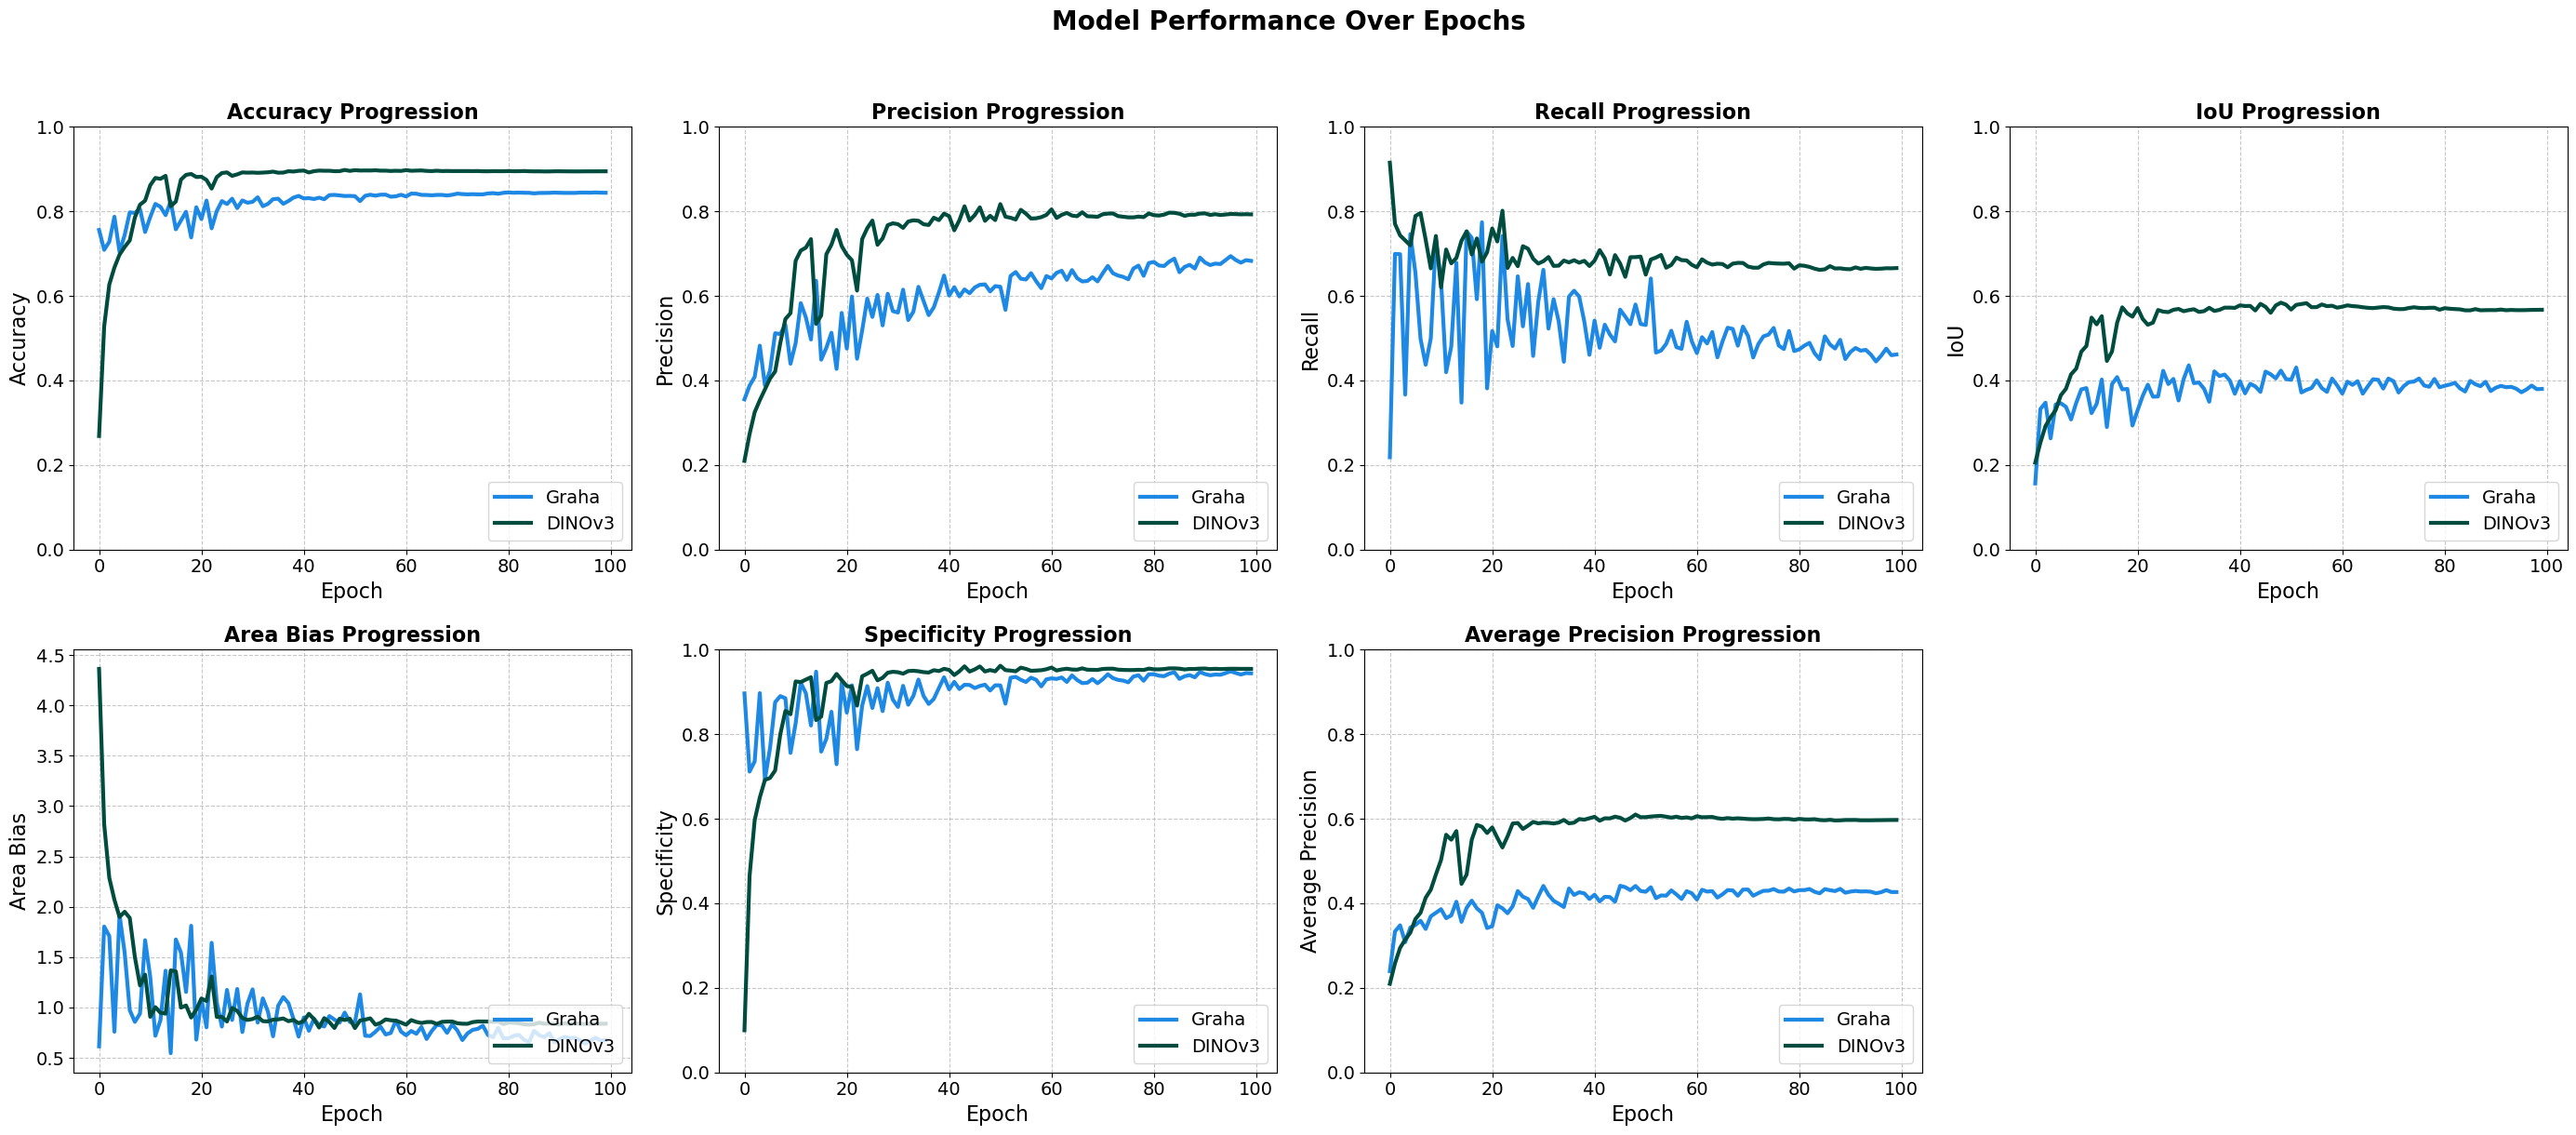

In [12]:

# Set colors
COLOR_GRAHA = "#1E88E5"
COLOR_DINO = "#004D40"

# 2 Rows, 4 Columns to fit 7 metrics
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
axes = axes.flatten()

metrics_to_plot = ["Accuracy", "Precision", "Recall", "IoU", "Area Bias", "Specificity", "Average Precision"]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # Plot Graha Line
    if metric in df_graha.columns and len(df_graha) > 0:
        ax.plot(df_graha["Epoch"], df_graha[metric], label="Graha", color=COLOR_GRAHA, linewidth=3)
        
    # Plot DINOv3 Line
    if metric in df_dino.columns and len(df_dino) > 0:
        ax.plot(df_dino["Epoch"], df_dino[metric], label="DINOv3", color=COLOR_DINO, linewidth=3)
        
    ax.set_title(f"{metric} Progression", fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    
    # Force Y-axis to 0-1 EXCEPT for Area Bias
    if metric != "Area Bias":
        ax.set_ylim(0, 1)
        
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='lower right')

# Hide the 8th empty subplot
axes[7].set_visible(False)

plt.suptitle("Model Performance Over Epochs", fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()